# Notebook 2 — Exploratory Data Analysis

**Business objective:** Explore the cleaned Berlin rental data to understand
pricing, occupancy, and guest satisfaction. The goal is to find patterns that
help answer the three project business questions.

For each chart I ask three questions:
1. What happened?
2. Why does it matter?
3. What business decision could this support?

**Steps in this notebook:**
1. Load the clean data
2. Prepare a priced-listings subset for fair price comparisons
3. Pricing analysis
4. Occupancy analysis
5. Guest satisfaction analysis
6. Neighborhood comparison
7. Superhost comparison

## Step 1 — Load the clean data

I load the cleaned listings file produced by Notebook 1, then set a
simple, consistent chart style so every chart in this notebook looks the
same.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

listings = pd.read_csv("../data/clean/listings_clean.csv")
print("Listings loaded:", listings.shape)

# A consistent look for every chart: a fixed size and a light background grid.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Listings loaded: (14274, 28)


## Step 2 — Prepare a priced-listings subset

For price analysis I only use listings that actually have a price. I also
remove very low and very high prices, because a few extreme values would pull
the average up and give a misleading picture of a typical listing.

I keep prices between 10 and 1,000 euros. I chose these limits because below
about 10 euros a night the entries are almost certainly errors or placeholder
values, and above 1,000 euros a night the listings are rare luxury cases that
are not representative of the normal market. This range keeps almost every
real listing while removing the handful of extreme outliers (the most
expensive listing in the raw data was 50,000 euros a night).

I use `.copy()` when creating this subset. This tells pandas to make a genuine
separate copy of the data, which avoids a common warning that appears when you
filter a table and then change it.

In [2]:
# Keep only listings that have a price.
priced = listings[listings["has_price"]].copy()

# Keep only realistic nightly prices, between 10 and 1,000 euros.
priced = priced[(priced["price"] >= 10) & (priced["price"] <= 1000)]

print("Listings used for price analysis:", len(priced))
print("Average nightly price: EUR", round(priced["price"].mean(), 2))
print("Median nightly price: EUR", round(priced["price"].median(), 2))

Listings used for price analysis: 9220
Average nightly price: EUR 129.45
Median nightly price: EUR 104.0


The average and the median are close to each other, which tells me the
trimmed price data is not badly skewed by extreme values. I will use this
`priced` subset for every price chart from here on.

## Step 3 — Pricing analysis

### Average price by room type

room_type
Hotel room         211.0
Entire home/apt    144.0
Private room        86.0
Shared room         48.0
Name: price, dtype: float64


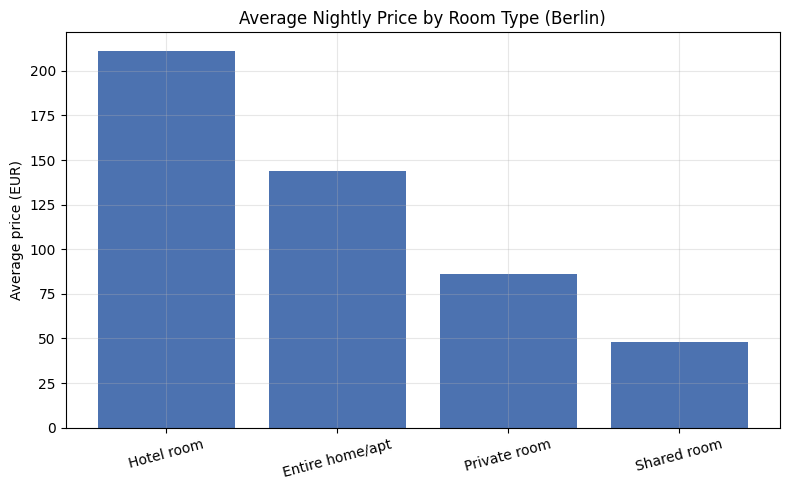

In [3]:
# Group the priced listings by room type and take the average price,
# then sort from the most expensive room type to the cheapest.
price_by_room = priced.groupby("room_type")["price"].mean().round(0)
price_by_room = price_by_room.sort_values(ascending=False)
print(price_by_room)

plt.bar(price_by_room.index, price_by_room.values, color="#4C72B0")
plt.title("Average Nightly Price by Room Type (Berlin)")
plt.ylabel("Average price (EUR)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/price_by_room_type.png", dpi=120)
plt.show()

**What happened:** Entire homes and hotel rooms cost the most per night,
while private and shared rooms are much cheaper.

**Why it matters:** Room type is one of the biggest drivers of price. A host
deciding how to list their space is also deciding their price range.

**Business decision:** A pricing tool should suggest different price bands for
each room type, instead of one city-wide average.

### Price distribution

A histogram groups the prices into bands and shows how many listings fall
into each band. It tells me where most listings sit and whether there is a
long tail of expensive ones.

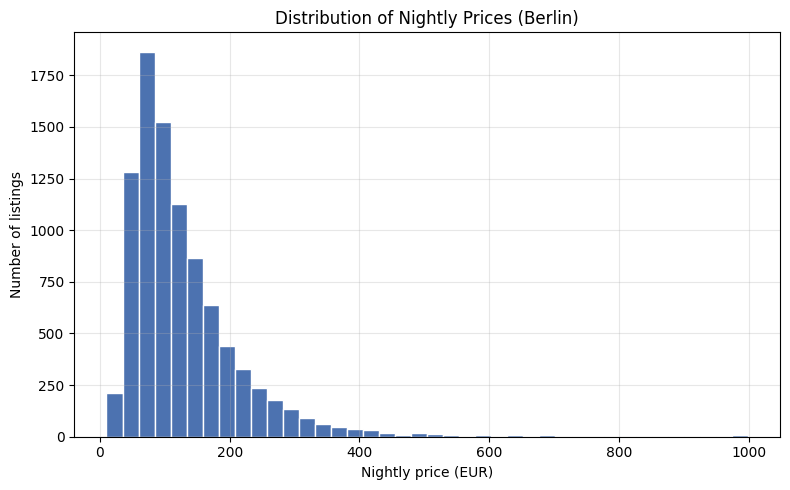

In [4]:
plt.hist(priced["price"], bins=40, color="#4C72B0", edgecolor="white")
plt.title("Distribution of Nightly Prices (Berlin)")
plt.xlabel("Nightly price (EUR)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.savefig("../outputs/price_distribution.png", dpi=120)
plt.show()

**What happened:** Most listings sit in the lower price range, with a long
tail of more expensive listings.

**Why it matters:** Berlin is mostly a mid-priced market. Very high prices are
the exception, not the norm.

**Business decision:** Marketing and pricing advice should focus on the large
group of mid-priced listings, since that is where most of the market is.

## Step 4 — Occupancy analysis

### Average occupancy rate by room type

Occupancy can use all listings, not just priced ones, because the
occupancy rate was estimated for every listing back in Notebook 1.

room_type
Shared room        39.1
Hotel room         23.5
Entire home/apt    22.3
Private room       18.2
Name: occupancy_rate, dtype: float64


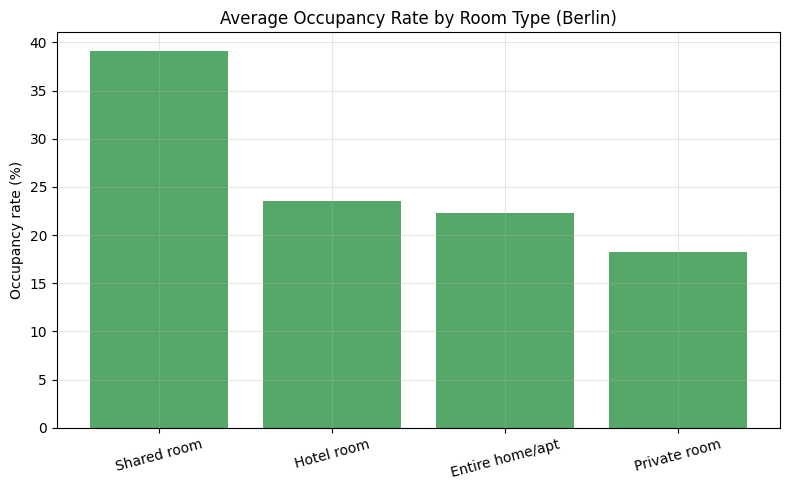

In [5]:
occupancy_by_room = listings.groupby("room_type")["occupancy_rate"].mean().round(1)
occupancy_by_room = occupancy_by_room.sort_values(ascending=False)
print(occupancy_by_room)

plt.bar(occupancy_by_room.index, occupancy_by_room.values, color="#55A868")
plt.title("Average Occupancy Rate by Room Type (Berlin)")
plt.ylabel("Occupancy rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/occupancy_by_room_type.png", dpi=120)
plt.show()

**What happened:** Occupancy rates differ by room type. This shows which
types of listings get booked more often across the year.

**Why it matters:** A high price only earns money if the listing actually gets
booked. Occupancy tells the other half of the revenue story.

**Business decision:** Hosts with low occupancy may need to adjust their price
or improve their listing, rather than assuming a higher price always means
more income.

### Price versus occupancy

A scatter plot puts one dot per listing, with price on one axis and
occupancy on the other. It lets me see whether expensive listings tend to get
booked less often.

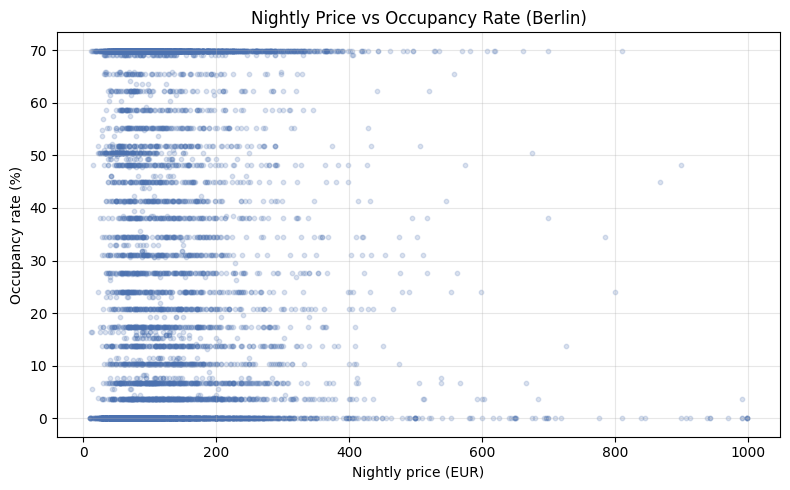

In [6]:
# One dot per priced listing. The alpha setting makes the dots slightly
# see-through, so overlapping points are easier to read.
plt.scatter(priced["price"], priced["occupancy_rate"],
            alpha=0.2, color="#4C72B0", s=10)
plt.title("Nightly Price vs Occupancy Rate (Berlin)")
plt.xlabel("Nightly price (EUR)")
plt.ylabel("Occupancy rate (%)")
plt.tight_layout()
plt.savefig("../outputs/price_vs_occupancy.png", dpi=120)
plt.show()

**What happened:** The dots are widely spread. There is no clear line
where a higher price always means lower occupancy.

**Why it matters:** It confirms that price alone does not decide how often a
listing is booked. Location, room type, and host quality matter too.

**Business decision:** Pricing advice should be combined with other factors,
not given on price alone.

## Step 5 — Guest satisfaction analysis

### Review score distribution

I look only at listings that already have a review score, since a listing
with no reviews has no score to show.

Listings with a review score: 10960
Average review score: 4.75


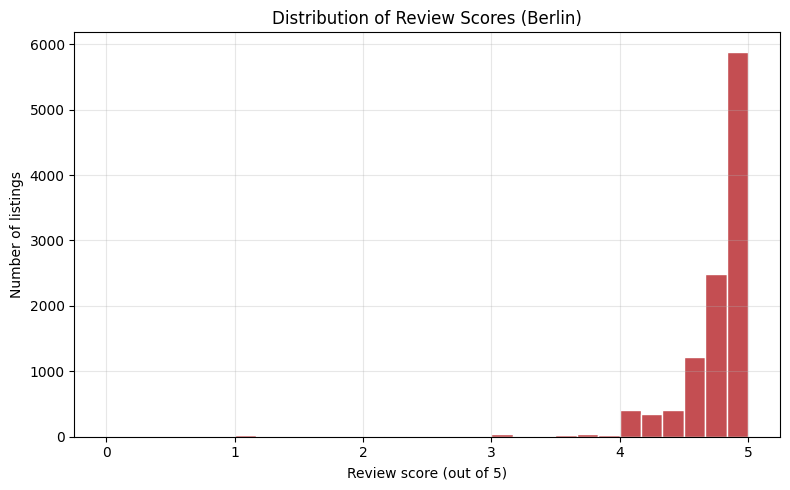

In [7]:
with_scores = listings[listings["review_scores_rating"].notna()]
print("Listings with a review score:", len(with_scores))
print("Average review score:", round(with_scores["review_scores_rating"].mean(), 2))

plt.hist(with_scores["review_scores_rating"], bins=30,
         color="#C44E52", edgecolor="white")
plt.title("Distribution of Review Scores (Berlin)")
plt.xlabel("Review score (out of 5)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.savefig("../outputs/review_score_distribution.png", dpi=120)
plt.show()

**What happened:** Most listings have high review scores, clustered near
the top of the scale.

**Why it matters:** Guests in Berlin generally rate their stays well, so a low
score stands out clearly and is a warning sign.

**Business decision:** Listings with below-average scores should be flagged
for support, because they are unusual in an otherwise high-rated market.

## Step 6 — Neighborhood comparison

Now I compare Berlin's 12 districts on price, occupancy, and review
score. This directly supports business question 1. I calculate each measure as
its own simple step, then combine them into one summary table.

In [8]:
# Number of listings in each district.
listings_per_district = listings.groupby("neighbourhood_group_cleansed")["id"].count()

# Average occupancy rate in each district.
occupancy_per_district = listings.groupby("neighbourhood_group_cleansed")["occupancy_rate"].mean()

# Average review score in each district.
score_per_district = listings.groupby("neighbourhood_group_cleansed")["review_scores_rating"].mean()

# Average price in each district, taken from the priced subset.
price_per_district = priced.groupby("neighbourhood_group_cleansed")["price"].mean()

# Combine the four measures into one table.
district_summary = pd.DataFrame({
    "listing_count": listings_per_district,
    "avg_occupancy": occupancy_per_district.round(1),
    "avg_review_score": score_per_district.round(2),
    "avg_price": price_per_district.round(0),
})

district_summary = district_summary.sort_values("listing_count", ascending=False)
district_summary

,listing_count,avg_occupancy,avg_review_score,avg_price
neighbourhood_group_cleansed,,,,
Friedrichshain-Kreuzberg,3108,21.8,4.77,125.0
Mitte,3102,22.8,4.73,153.0
Pankow,2164,23.1,4.77,136.0
Neukölln,1532,16.2,4.77,111.0
Charlottenburg-Wilm.,1529,19.6,4.71,130.0
Tempelhof - Schöneberg,952,23.1,4.75,118.0
Treptow - Köpenick,632,18.0,4.77,109.0
Lichtenberg,413,20.8,4.73,116.0
Steglitz - Zehlendorf,388,19.1,4.78,105.0


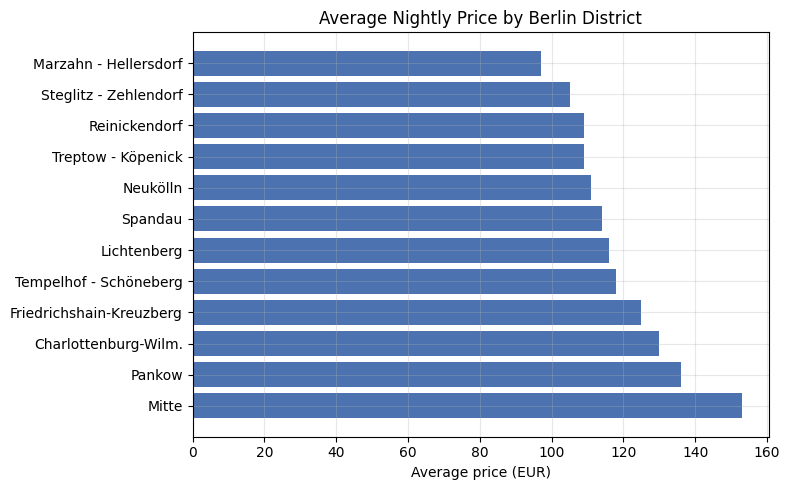

In [9]:
# Horizontal bar chart of average price per district, sorted high to low.
price_by_district = district_summary["avg_price"].sort_values(ascending=False)

plt.barh(price_by_district.index, price_by_district.values, color="#4C72B0")
plt.title("Average Nightly Price by Berlin District")
plt.xlabel("Average price (EUR)")
plt.tight_layout()
plt.savefig("../outputs/price_by_district.png", dpi=120)
plt.show()

**What happened:** Prices vary clearly between districts. Central
districts tend to be more expensive than outer ones.

**Why it matters:** Location is a strong driver of price in Berlin.

**Business decision:** Pricing benchmarks should be set per district, so a
host is compared with similar listings nearby, not with the whole city.

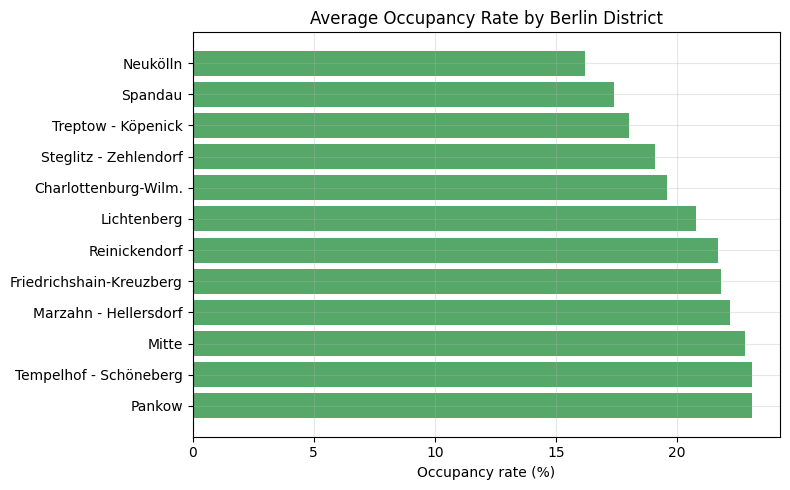

In [10]:
# Horizontal bar chart of average occupancy per district, sorted high to low.
occ_by_district = district_summary["avg_occupancy"].sort_values(ascending=False)

plt.barh(occ_by_district.index, occ_by_district.values, color="#55A868")
plt.title("Average Occupancy Rate by Berlin District")
plt.xlabel("Occupancy rate (%)")
plt.tight_layout()
plt.savefig("../outputs/occupancy_by_district.png", dpi=120)
plt.show()

**What happened:** Some districts have noticeably higher occupancy than
others.

**Why it matters:** A district with high occupancy and a fair price is a
strong performer. A district with a high price but low occupancy may be
overpriced.

**Business decision:** This comparison helps identify which districts give
hosts the best balance of price and demand.

## Step 7 — Superhost comparison

Finally I compare superhosts with non-superhosts on occupancy, review
score, and price. This supports business question 3. I use the same
step-by-step approach as the district comparison: one measure per step, then
combine.

In [11]:
# Average occupancy rate for each host group.
occupancy_per_host = listings.groupby("host_is_superhost")["occupancy_rate"].mean()

# Average review score for each host group.
score_per_host = listings.groupby("host_is_superhost")["review_scores_rating"].mean()

# Average price for each host group, from the priced subset.
price_per_host = priced.groupby("host_is_superhost")["price"].mean()

# Combine the three measures into one table.
superhost_summary = pd.DataFrame({
    "avg_occupancy": occupancy_per_host.round(1),
    "avg_review_score": score_per_host.round(2),
    "avg_price": price_per_host.round(0),
})

superhost_summary

,avg_occupancy,avg_review_score,avg_price
host_is_superhost,,,
No,13.0,4.71,124.0
Unknown,44.4,4.74,138.0
Yes,44.6,4.86,140.0


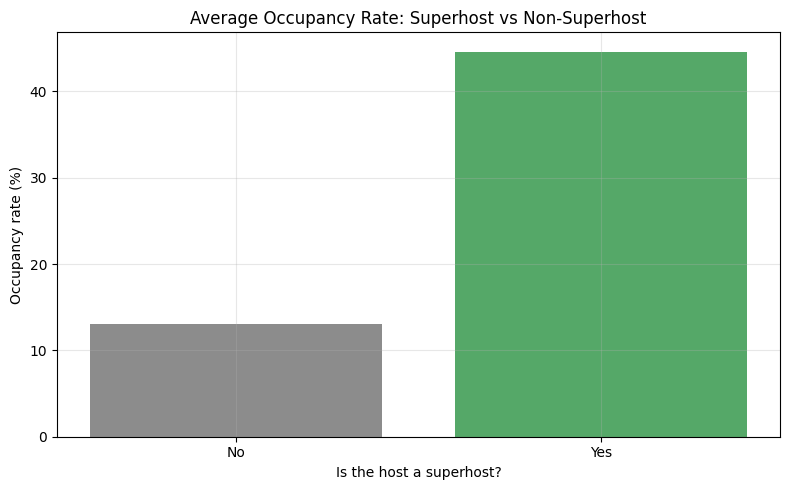

In [12]:
# Compare occupancy for "No" versus "Yes". The small "Unknown" group is
# left out so the comparison is a clean two-way contrast.
compare = superhost_summary.loc[["No", "Yes"], "avg_occupancy"]

plt.bar(compare.index, compare.values, color=["#8C8C8C", "#55A868"])
plt.title("Average Occupancy Rate: Superhost vs Non-Superhost")
plt.ylabel("Occupancy rate (%)")
plt.xlabel("Is the host a superhost?")
plt.tight_layout()
plt.savefig("../outputs/superhost_occupancy.png", dpi=120)
plt.show()

**What happened:** Superhosts have a much higher average occupancy rate
than non-superhosts.

**Why it matters:** Superhost status is linked to real marketplace
performance, not just a badge. Better-rated, more responsive hosts get booked
more often.

**Business decision:** Encouraging hosts to reach and keep superhost status is
a realistic way to improve overall marketplace performance.

## Insight summary

- **Room type** is a major driver of both price and occupancy.
- **Location matters:** prices and occupancy differ clearly between Berlin's
  12 districts.
- **Price alone does not decide occupancy** — the price versus occupancy chart
  was widely spread.
- **Review scores are high overall**, so low scores are a clear warning sign.
- **Superhosts strongly outperform non-superhosts** on occupancy.

## Business recommendation

The marketplace should set pricing and performance benchmarks per district and
per room type, not city-wide. It should also support low-rated listings early
and help hosts work toward superhost status, since superhosts deliver clearly
better occupancy. These findings are explored further with SQL in the next
stage and summarised for the Tableau dashboard in Notebook 3.